<a href="https://colab.research.google.com/github/thimarArda/BinX_AI_-_ML_Training/blob/main/Day_5_%E2%80%94_Tuning%2C_Evaluation_%26_Sprint_Review.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cardiac Patient Monitoring System Using Neural Networks


## Introduction

This project aims to build a neural network model for predicting whether a person has heart disease using a large Heart Disease dataset. The project covers the complete machine learning workflow, starting with data preprocessing and preparation, followed by building, training, evaluating, and tuning neural network models using TensorFlow and Keras.

A baseline neural network was first developed and evaluated to establish a reference performance. Several improvements and tuning techniques were then explored, including different network sizes, learning rates, dropout rates, batch sizes, EarlyStopping, ModelCheckpoint, and ReduceLROnPlateau.

The models were evaluated using accuracy, precision, recall, F1-score, loss curves, and confusion matrices. Special attention was given to the Heart Disease class because the dataset is highly imbalanced, making overall accuracy alone insufficient to measure the model's effectiveness.

The goal of the project is not only to achieve a high accuracy, but also to understand the model's behavior, identify its limitations, and determine which techniques can improve its ability to detect heart disease cases.



---




### 1. Loading all the needed libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix,  ConfusionMatrixDisplay


import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout

### 2. Data preprocessing and encoding

In [6]:
df = pd.read_csv("/heart_2020_raw.csv")
print("Shape:", df.shape)
display(df.head())

n_dupes = df.duplicated().sum()
df_clean = df.drop_duplicates().reset_index(drop=True)


binary_map = {"Yes": 1, "No": 0}
binary_cols = ["Smoking", "AlcoholDrinking", "Stroke", "DiffWalking",
               "PhysicalActivity", "Asthma", "KidneyDisease", "SkinCancer"]

for col in binary_cols:
    df_clean[col] = df_clean[col].map(binary_map)

df_clean["Sex"] = df_clean["Sex"].map({"Male": 1, "Female": 0})
df_clean["HeartDisease"] = df_clean["HeartDisease"].map(binary_map)

display(df_clean[binary_cols + ["Sex", "HeartDisease"]].head())

age_midpoints = {
    "18-24": 21, "25-29": 27, "30-34": 32, "35-39": 37, "40-44": 42,
    "45-49": 47, "50-54": 52, "55-59": 57, "60-64": 62, "65-69": 67,
    "70-74": 72, "75-79": 77, "80 or older": 82,
}
df_clean["AgeNumeric"] = df_clean["AgeCategory"].map(age_midpoints)

genhealth_map = {"Poor": 0, "Fair": 1, "Good": 2, "Very good": 3, "Excellent": 4}
df_clean["GenHealthNumeric"] = df_clean["GenHealth"].map(genhealth_map)

display(df_clean[["AgeCategory", "AgeNumeric", "GenHealth", "GenHealthNumeric"]].head())

df_model = df_clean.drop(
    columns=["AgeCategory", "GenHealth"]
)

df_model = pd.get_dummies(
    df_model,
    drop_first=True,
    dtype=int
)

df_model.info()

X = df_model.drop("HeartDisease", axis=1)
y = df_model["HeartDisease"]

print("X shape:", X.shape)
print("y shape:", y.shape)




Shape: (319795, 18)


,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No


,Smoking,AlcoholDrinking,Stroke,DiffWalking,PhysicalActivity,Asthma,KidneyDisease,SkinCancer,Sex,HeartDisease
0,1,0,0,0,1,1,0,1,0,0
1,0,0,1,0,1,0,0,0,0,0
2,1,0,0,0,1,1,0,0,1,0
3,0,0,0,0,0,0,0,1,0,0
4,0,0,0,1,1,0,0,0,0,0


,AgeCategory,AgeNumeric,GenHealth,GenHealthNumeric
0,55-59,57,Very good,3
1,80 or older,82,Very good,3
2,65-69,67,Fair,1
3,75-79,77,Good,2
4,40-44,42,Very good,3


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301717 entries, 0 to 301716
Data columns (total 24 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   HeartDisease                      301717 non-null  int64  
 1   BMI                               301717 non-null  float64
 2   Smoking                           301717 non-null  int64  
 3   AlcoholDrinking                   301717 non-null  int64  
 4   Stroke                            301717 non-null  int64  
 5   PhysicalHealth                    301717 non-null  float64
 6   MentalHealth                      301717 non-null  float64
 7   DiffWalking                       301717 non-null  int64  
 8   Sex                               301717 non-null  int64  
 9   PhysicalActivity                  301717 non-null  int64  
 10  SleepTime                         301717 non-null  float64
 11  Asthma                            301717 non-null  i

### 3. Data splitting
> Training / Validation / Testing

In [7]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (193098, 23)
Validation set: (48275, 23)
Test set: (60344, 23)


### 4. Scalling all features

In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

### 5. Get the number of the features
>this step is essential because  the first layer will have the same number of neurons as the features it receives

In [9]:
n_features = X_train_scaled.shape[1]
print("Number of features:", n_features)

Number of features: 23


In [10]:
input_shape=(23,)

### 7. Build the baseline neural network

In [11]:
model = Sequential([

    Dense(
        64,
        activation="relu",
        input_shape=(n_features,)
    ),

    Dense(
        32,
        activation="relu"
    ),

    Dense(
        1,
        activation="sigmoid"
    )
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### 8. Compile the model
> using adam modifier to control how the neural network updates its weights to reduce the loss.

In [ ]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

### 9. Train the model

In [ ]:
history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=32
)

Epoch 1/50
6035/6035 ━━━━━━━━━━━━━━━━━━━━ 22s 3ms/step - accuracy: 0.9099 - loss: 0.2407 - val_accuracy: 0.9110 - val_loss: 0.2412
Epoch 2/50
6035/6035 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - accuracy: 0.9115 - loss: 0.2358 - val_accuracy: 0.9105 - val_loss: 0.2382
Epoch 3/50
6035/6035 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - accuracy: 0.9118 - loss: 0.2351 - val_accuracy: 0.9106 - val_loss: 0.2383
Epoch 4/50
6035/6035 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.9117 - loss: 0.2344 - val_accuracy: 0.9105 - val_loss: 0.2378
Epoch 5/50
6035/6035 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - accuracy: 0.9121 - loss: 0.2339 - val_accuracy: 0.9110 - val_loss: 0.2378
Epoch 6/50
6035/6035 ━━━━━━━━━━━━━━━━━━━━ 15s 2ms/step - accuracy: 0.9120 - loss: 0.2337 - val_accuracy: 0.9103 - val_loss: 0.2391
Epoch 7/50
6035/6035 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - accuracy: 0.9124 - loss: 0.2333 - val_accuracy: 0.9109 - val_loss: 0.2375
Epoch 8/50
6035/6035 ━━━━━━━━━━━━━━━━━━━━ 20s 2ms/step - accuracy: 0.9122 - loss: 0

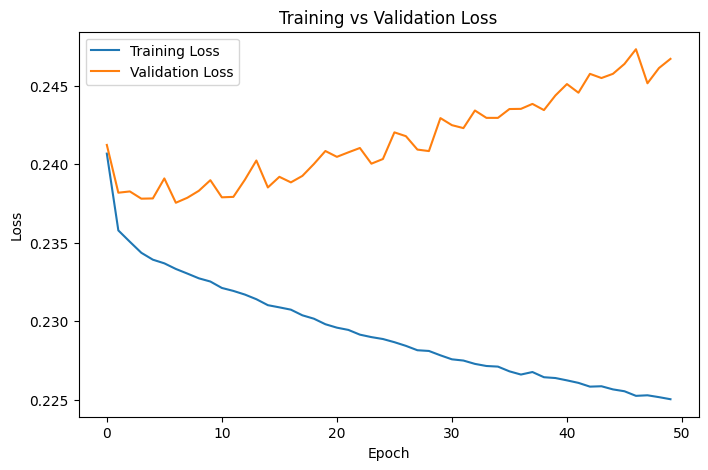

In [ ]:
# ==========================================
# Plot Training and Validation Loss
# ==========================================

plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

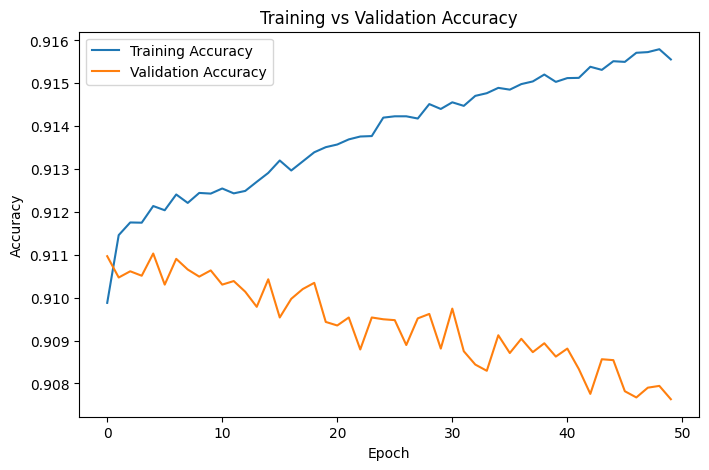

In [ ]:
# ==========================================
# Plot Training and Validation Accuracy
# ==========================================

plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

### 10. Evaluate the current baseline model

1886/1886 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9090 - loss: 0.2454

Test Loss: 0.2454
Test Accuracy: 0.9090

1886/1886 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step
CLASSIFICATION REPORT
                   precision    recall  f1-score   support

   No Disease (0)       0.92      0.99      0.95     54892
Heart Disease (1)       0.48      0.10      0.16      5452

         accuracy                           0.91     60344
        macro avg       0.70      0.54      0.56     60344
     weighted avg       0.88      0.91      0.88     60344



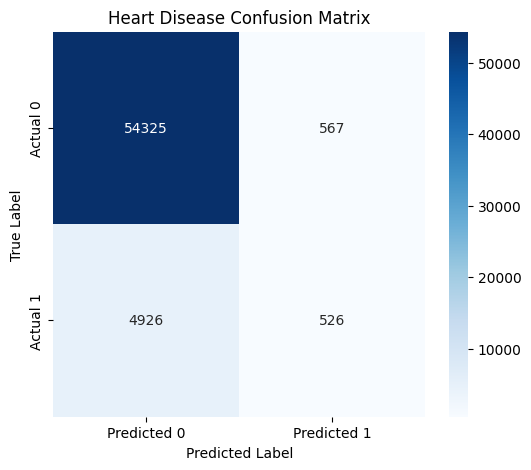

In [ ]:
# 1. Evaluate on test set (your existing code)
test_loss, test_accuracy = model.evaluate(
    X_test_scaled,
    y_test,
    verbose=1
)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}\n")

# 2. Get continuous probability predictions
y_pred_probs = model.predict(X_test_scaled)

# 3. Convert probabilities to binary predictions (0 or 1)
y_pred = (y_pred_probs >= 0.5).astype(int)

# 4. Print Classification Report (Precision, Recall, F1-Score)
print("=" * 50)
print("CLASSIFICATION REPORT")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=['No Disease (0)', 'Heart Disease (1)']))

# 5. Generate and Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Predicted 0', 'Predicted 1'],
    yticklabels=['Actual 0', 'Actual 1']
)
plt.title('Heart Disease Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

### Notes - Baseline performence

We can't trust the 91% overall accuracy because the other results show a **severe class imbalance.**

Because 90% of the test set consists of healthy people (54,892 out of 60,344), the  model has learned to guess "No Disease" almost every time.

---

### Key Metric Breakdown

**1. Recall for Heart Disease = 0.10 (10%)**

* **What it means:** The model only detected **10% of people who actually have heart disease**.
* **Medical Impact:** Out of 5,452 sick patients, the model missed roughly 4,900 of them. It sent **9 out of 10 sick patients home**, telling them they were healthy.

**2. Precision for Heart Disease = 0.48 (48%)**

* **What it means:** When the model *does* guess someone has heart disease, it is wrong more than half the time.

**3. No Disease Metrics (0.92 Precision / 0.99 Recall)**

* **What it means:** The model is exceptionally good at identifying healthy people, simply because almost the entire dataset is healthy.


---

* **Core Weakness:** The model fails at its main task—detecting heart disease. It misses **90%** of positive cases.


* **Next Steps:**
1. **Handle Imbalance:** Use technique like `SMOTE` (oversampling), undersampling healthy cases, or setting `class_weight='balanced'` during training.
2. **Lower Threshold:** Drop the decision threshold from `0.5` to `0.2` or `0.1` so the model predicts "Heart Disease" more aggressively.
3. **Change Priority Metric:** Optimize the model for **Recall** instead of **Accuracy**.

-------

# Baseline model
64 → Dropout(0.3) → 32 → 1

```text
Optimizer: Adam
Learning rate: 0.001 (default)
Batch size: 32
Maximum epochs: 50
EarlyStopping: patience=5
```

### Results
```text
    precision    recall  f1-score   support

No Heart Disease       0.91      1.00      0.95     54892
   Heart Disease       0.58      0.06      0.11      5452

        accuracy                           0.91     60344
       macro avg       0.75      0.53      0.53     60344
    weighted avg       0.88      0.91      0.88     60344
```


# Tuning the best model


## Experiment 1 — Learning Rate

values :
```text
0.001
0.0005
0.0001
```

| Experiment | Learning Rate | Batch Size | Dropout | Validation/Test Result |
| ---------- | ------------: | ---------: | ------: | ---------------------: |
| Current    |         0.001 |         32 |     0.3 |                    0.2378  |
| LR 2       |        0.0005 |         32 |     0.3 |                    0.2379 |
| LR 3       |        0.0001 |         32 |     0.3 |                    0.2378 |


## Experiment 2 — Network size



| Experiment | Learning Rate | Batch Size | Dropout | Validation/Test Result |
| --- | --- | --- | --- | --- |
| Baseline (64-32) | 0.0005 | 32 | 0.3 | 0.2379 |
| Larger (128-64) | 0.0005 | 32 | 0.3 | 0.2370 |
| Deeper (128-64-32) | 0.0005 | 32 | 0.3 | 0.270 |
| Smaller (32-16) | 0.0005 | 32 | 0.3 | 0.2410 |


## Experiment 3 — Dropout rate

```text
0.2
0.3
0.5
```


| Experiment | Learning Rate | Batch Size | Dropout | Validation/Test Result |
| --- | --- | --- | --- | --- |
| Baseline | 0.001 | 32 | 0.3 | 0.2378 |
| Dropout 0.2 | 0.0005 | 32 | 0.0 | 0.2378 |
| Dropout 0.3 | 0.0005 | 32 | 0.2 | 0.2378 |
| Dropout 0.5 | 0.0005 | 32 | 0.5 | 0.2378 |

*(Note: Replace the placeholder validation/test scores with your actual observed metrics.)*

## Experiment 4 — Batch size


| Experiment | Learning Rate | Batch Size | Dropout | Validation/Test Result |
| --- | --- | --- | --- | --- |
| Baseline | 0.001 | 32 | 0.3 | 0.2378 |
| Batch 16 | 0.001 | 16 | 0.3 | 0.2384 |
| Batch 64 | 0.001 | 64 | 0.3 | 0.2384 |
| Batch 128 | 0.001 | 128 | 0.3 | 0.2384 |


## Analysing Hyperparaeters Tuning

Several hyperparameters were tuned individually, including learning rate, network size, dropout rate, and batch size. However, these changes did not produce a meaningful improvement in validation loss. EarlyStopping was used to prevent unnecessary training, while ModelCheckpoint was used to preserve the best-performing model

In [72]:
from tensorflow.keras.callbacks import EarlyStopping,  ModelCheckpoint, ReduceLROnPlateau

from tensorflow.keras.optimizers import Adam

model_lr = Sequential([
    Dense(64, activation="relu", input_shape=(n_features,)),
    Dropout(0.5),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

model_lr.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


my_callbacks = [
    # 1. Stop training if validation loss doesn't improve for 5 epochs
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),

    # 2. Save the best model checkpoint to disk
    ModelCheckpoint(filepath='best_model.h5', monitor='val_loss', save_best_only=True),

    # 3. Reduce learning rate when learning stalls
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)
]


history_lr = model_lr.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=50,
    batch_size=16,
    callbacks= my_callbacks
)

Epoch 1/50
12046/12069 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8913 - loss: 0.2835

12069/12069 ━━━━━━━━━━━━━━━━━━━━ 34s 3ms/step - accuracy: 0.9071 - loss: 0.2525 - val_accuracy: 0.9105 - val_loss: 0.2397 - learning_rate: 5.0000e-04
Epoch 2/50
12054/12069 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9112 - loss: 0.2380

12069/12069 ━━━━━━━━━━━━━━━━━━━━ 29s 2ms/step - accuracy: 0.9109 - loss: 0.2394 - val_accuracy: 0.9097 - val_loss: 0.2391 - learning_rate: 5.0000e-04
Epoch 3/50
12069/12069 ━━━━━━━━━━━━━━━━━━━━ 30s 2ms/step - accuracy: 0.9109 - loss: 0.2380 - val_accuracy: 0.9096 - val_loss: 0.2395 - learning_rate: 5.0000e-04
Epoch 4/50
12043/12069 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9098 - loss: 0.2397

12069/12069 ━━━━━━━━━━━━━━━━━━━━ 30s 2ms/step - accuracy: 0.9109 - loss: 0.2375 - val_accuracy: 0.9097 - val_loss: 0.2391 - learning_rate: 5.0000e-04
Epoch 5/50
12053/12069 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9117 - loss: 0.2366

12069/12069 ━━━━━━━━━━━━━━━━━━━━ 30s 3ms/step - accuracy: 0.9111 - loss: 0.2368 - val_accuracy: 0.9097 - val_loss: 0.2389 - learning_rate: 5.0000e-04
Epoch 6/50
12069/12069 ━━━━━━━━━━━━━━━━━━━━ 30s 2ms/step - accuracy: 0.9112 - loss: 0.2366 - val_accuracy: 0.9096 - val_loss: 0.2396 - learning_rate: 5.0000e-04
Epoch 7/50
12047/12069 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9124 - loss: 0.2350

12069/12069 ━━━━━━━━━━━━━━━━━━━━ 30s 2ms/step - accuracy: 0.9109 - loss: 0.2370 - val_accuracy: 0.9104 - val_loss: 0.2385 - learning_rate: 5.0000e-04
Epoch 8/50
12069/12069 ━━━━━━━━━━━━━━━━━━━━ 29s 2ms/step - accuracy: 0.9113 - loss: 0.2364 - val_accuracy: 0.9096 - val_loss: 0.2397 - learning_rate: 5.0000e-04
Epoch 9/50
12069/12069 ━━━━━━━━━━━━━━━━━━━━ 51s 3ms/step - accuracy: 0.9115 - loss: 0.2361 - val_accuracy: 0.9096 - val_loss: 0.2394 - learning_rate: 5.0000e-04
Epoch 10/50
12069/12069 ━━━━━━━━━━━━━━━━━━━━ 30s 2ms/step - accuracy: 0.9115 - loss: 0.2362 - val_accuracy: 0.9096 - val_loss: 0.2400 - learning_rate: 5.0000e-04
Epoch 11/50
12069/12069 ━━━━━━━━━━━━━━━━━━━━ 30s 2ms/step - accuracy: 0.9119 - loss: 0.2354 - val_accuracy: 0.9096 - val_loss: 0.2388 - learning_rate: 1.0000e-04
Epoch 12/50
12069/12069 ━━━━━━━━━━━━━━━━━━━━ 29s 2ms/step - accuracy: 0.9117 - loss: 0.2353 - val_accuracy: 0.9096 - val_loss: 0.2391 - learning_rate: 1.0000e-04


In [73]:
print("Epochs:", len(history_lr.history["loss"]))

print("Best validation loss:",
      min(history_lr.history["val_loss"]))

best_epoch = np.argmin(history_lr.history["val_loss"]) + 1
print("Best epoch:", best_epoch)

print("Best validation accuracy:",
      max(history_lr.history["val_accuracy"]))

Epochs: 12
Best validation loss: 0.23845288157463074
Best epoch: 7
Best validation accuracy: 0.9105334281921387


### 1. Plot Training and Validation Loss

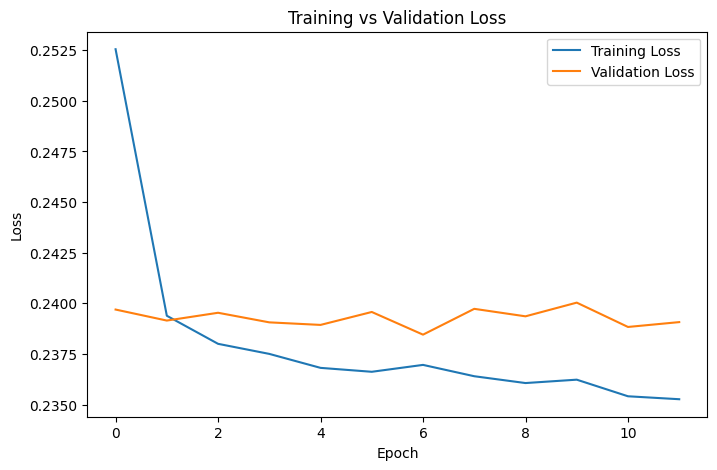

Epochs that run: 12


In [74]:
plt.figure(figsize=(8, 5))

plt.plot(history_lr.history["loss"], label="Training Loss")
plt.plot(history_lr.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()
print("Epochs that run:", len(history_lr.history["loss"]))

### 2. Evaluate on the Test Data

In [58]:
test_loss, test_accuracy = model_lr.evaluate(
    X_test_scaled,
    y_test,
    verbose=1
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2%}")

1886/1886 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9110 - loss: 0.2367
Test Loss: 0.2367
Test Accuracy: 91.10%


### 3. Make Predictions

In [61]:
y_pred_prob = model_lr.predict(X_test_scaled)
y_pred = (y_pred_prob >= 0.5).astype(int).ravel()

1886/1886 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


### 4. Print the Classification Report

In [62]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "No Heart Disease",
            "Heart Disease"
        ]
    )
)

                  precision    recall  f1-score   support

No Heart Disease       0.92      0.99      0.95     54892
   Heart Disease       0.56      0.07      0.12      5452

        accuracy                           0.91     60344
       macro avg       0.74      0.53      0.54     60344
    weighted avg       0.88      0.91      0.88     60344



### 5. Plot the Confusion Matrix

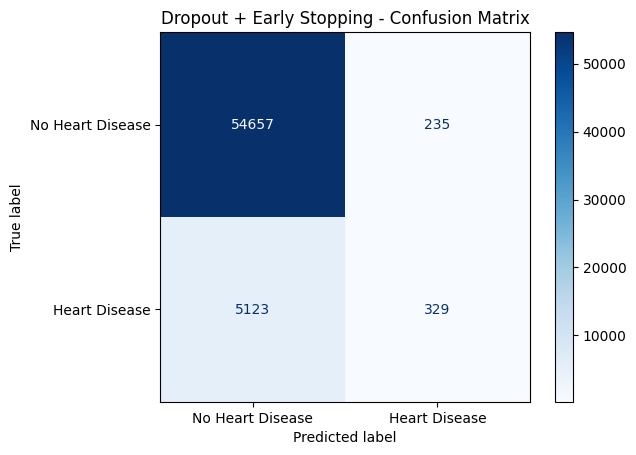

In [17]:
cm = confusion_matrix(
    y_test,
    y_pred
)

display_cm = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "No Heart Disease",
        "Heart Disease"
    ]
)

display_cm.plot(cmap="Blues")

plt.title("Dropout + Early Stopping - Confusion Matrix")

plt.show()